# Example use for single fund (Artemis)
## save data

In [1]:
from Base.BaseDataHelper import BaseDataHelper
from MarketData.FundList import Fund
import Globals.Functions as gf
import Globals.Variables as gv

fund = Fund(isin="GB00B5N99561", full_name="Artemis Global Income Fund Inc")

fromYahoo = True
data = gf.get_data(fund, gv.start_date, gv.end_date, fromYahoo)
helper = BaseDataHelper("/Data/Yahoo/", fund.full_name + "_" + gv.start_date + "_" + gv.end_date + ".csv", data)
helper.save_data_frame()

## Plot 

[*********************100%***********************]  1 of 1 completed


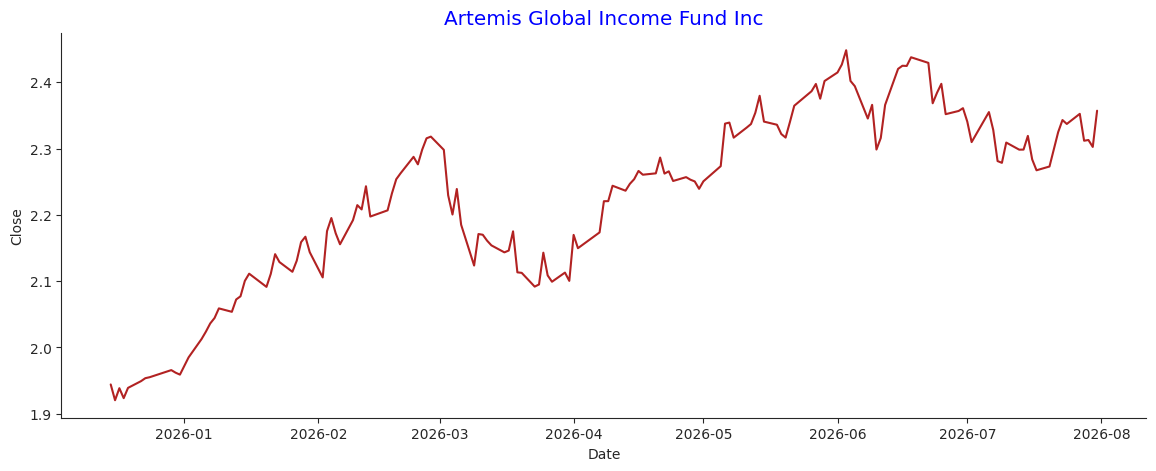

Mean:  2.2282696095379917
Absolute Growth:  17.522846475889626
Growth on Mean:  5.470125447627916
Volatility:  0.00757519535199778


In [2]:
from MarketData.MarketDataHelper import MarketDataHelper
from MarketData.FundList import Fund
from MarketData.MarketDataPlotter import MarketDtaPlotter
from MarketData.FundDataAnalyser import FundAnalyser
import Globals.Functions as gf
import Globals.Variables as gv


try:
  fund = Fund(isin="GB00B5N99561", full_name="Artemis Global Income Fund Inc")
  # Can be much quicker to save data first for multiple runs
  fromYahoo = True
  data = gf.get_data(fund, gv.start_date, gv.end_date, fromYahoo)
  data = data.reset_index()
  # yfinance returns MultiIndex columns (Price, Ticker); flatten so 'Date'/'Close' are plain columns
  data.columns = data.columns.get_level_values(0)
  helper = MarketDataHelper(data, gv.start_date, gv.end_date)
  fund.set_data_helper(helper)
  plotter = MarketDtaPlotter(helper)
  plotter.plot_sns("Date", "Close", fund.full_name)
except Exception as e:
  print("An error occurred: ", e)

try:
  analyser = FundAnalyser(fund)
  mean = analyser.close_mean
  absGrowth = analyser.get_abs_growth()
  growthOnMean = analyser.get_growth_on_mean()
  vol = analyser.get_volatility()
  fund.set_indicators(mean, absGrowth, growthOnMean, vol)
except Exception as e:
  print("An error occurred: ", e)
finally:
  print("Mean: ", mean)
  print("Absolute Growth: ", absGrowth)
  print("Growth on Mean: ", growthOnMean)
  print("Volatility: ", vol)

fund.set_indicators(mean, absGrowth, growthOnMean, vol)

# Compare Quantum computing companies


## general plotter functions

In [8]:
from MarketData.FundList import QuantumCompanyList, QuantumAdjacentCompanyList
import Globals.Functions as gf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def format_market_cap(value):
    if value is None:
        return "N/A"
    if value >= 1_000_000_000:
        return f"${value / 1_000_000_000:.1f}B"
    if value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    return f"${value:,.0f}"

def plot_normalised_comparison(fund_list_cls, title):
    fund_list = fund_list_cls()
    start_date = (pd.Timestamp.today() - pd.DateOffset(years=5)).strftime('%Y-%m-%d')
    end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

    gf.populate_all_fund_data(start_date, end_date, fund_list)

    plt.figure(figsize=(14, 6))
    sns.set_style("ticks")
    for fund_key, fund in fund_list.items():
        if fund.data_helper is None:
            continue
        data = fund.data_helper.get_data_frame()
        # index each series to 100 at its start so companies are comparable regardless of share price
        normalised = data['Close'] / data['Close'].iloc[0] * 100
        label = f"{fund.full_name} ({format_market_cap(fund.market_cap)})"
        sns.lineplot(x=data['Date'], y=normalised, label=label)

    sns.despine()
    plt.title(title, size='x-large', color='blue')
    plt.xlabel("Date")
    plt.ylabel("Normalised Price (start = 100)")
    plt.legend()
    plt.show()

    return fund_list

## QC companies

Submitted: IonQ
Submitted: Rigetti
Submitted: D-Wave
Submitted: Quantum
[D-Wave] OK
[Rigetti] OK
[IonQ] OK
[Quantum] OK


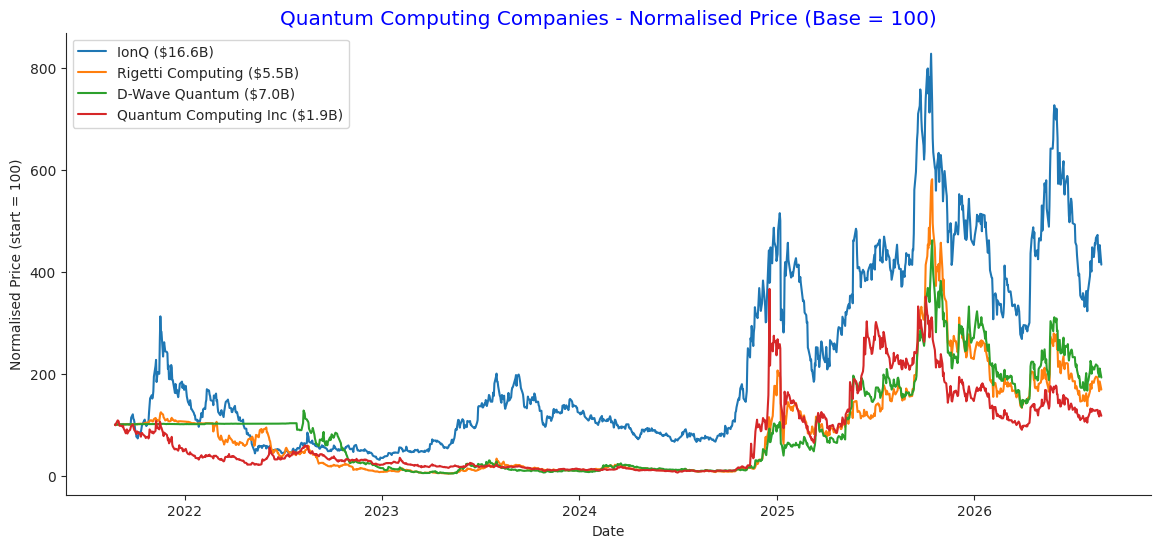

In [9]:
quantum_list = plot_normalised_comparison(
    QuantumCompanyList,
    "Quantum Computing Companies - Normalised Price (Base = 100)"
)


## QC Adjacent Companies


1 Failed download:
['']: ValueError('Empty ticker name')


Submitted: IBM
Submitted: Alphabet
Submitted: Microsoft
Submitted: Intel
Submitted: NVIDIA
[Alphabet] FAILED: empty data from Yahoo
[NVIDIA] OK
[Intel] OK
[IBM] OK
[Microsoft] OK


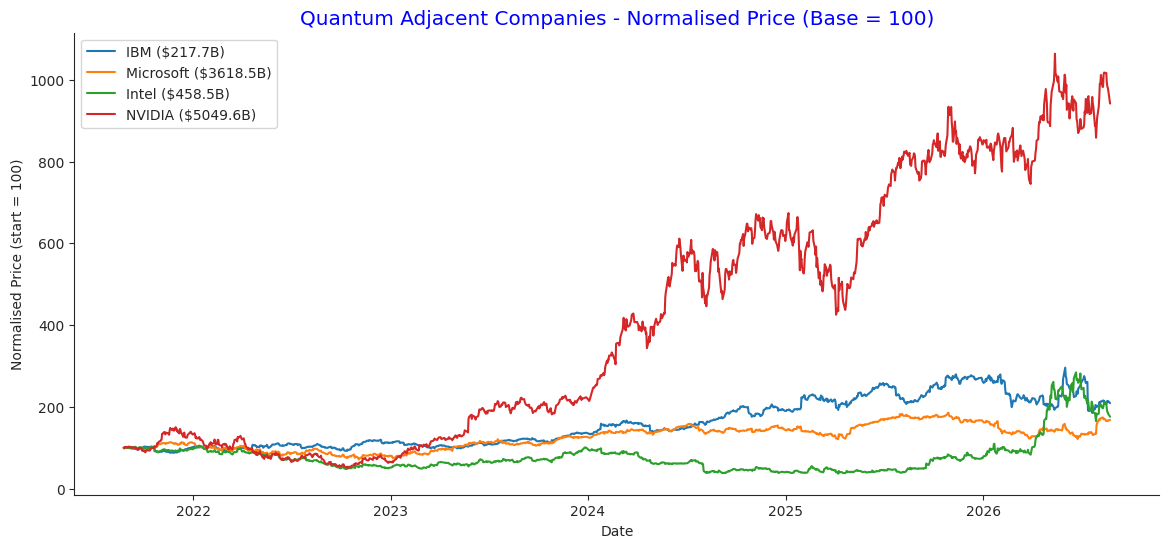

In [10]:
from MarketData.FundList import QuantumAdjacentCompanyList
import Globals.Functions as gf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

quantum_adjacent_list = plot_normalised_comparison(
    QuantumAdjacentCompanyList,
    "Quantum Adjacent Companies - Normalised Price (Base = 100)"
)


##  Combined


1 Failed download:
['']: ValueError('Empty ticker name')


Submitted: IonQ
Submitted: Rigetti
Submitted: D-Wave
Submitted: Quantum
Submitted: IBM
Submitted: Alphabet
Submitted: Microsoft
Submitted: Intel
Submitted: NVIDIA
[Alphabet] FAILED: empty data from Yahoo
[IonQ] OK
[Quantum] OK
[Rigetti] OK
[D-Wave] OK
[NVIDIA] OK
[IBM] OK
[Microsoft] OK
[Intel] OK


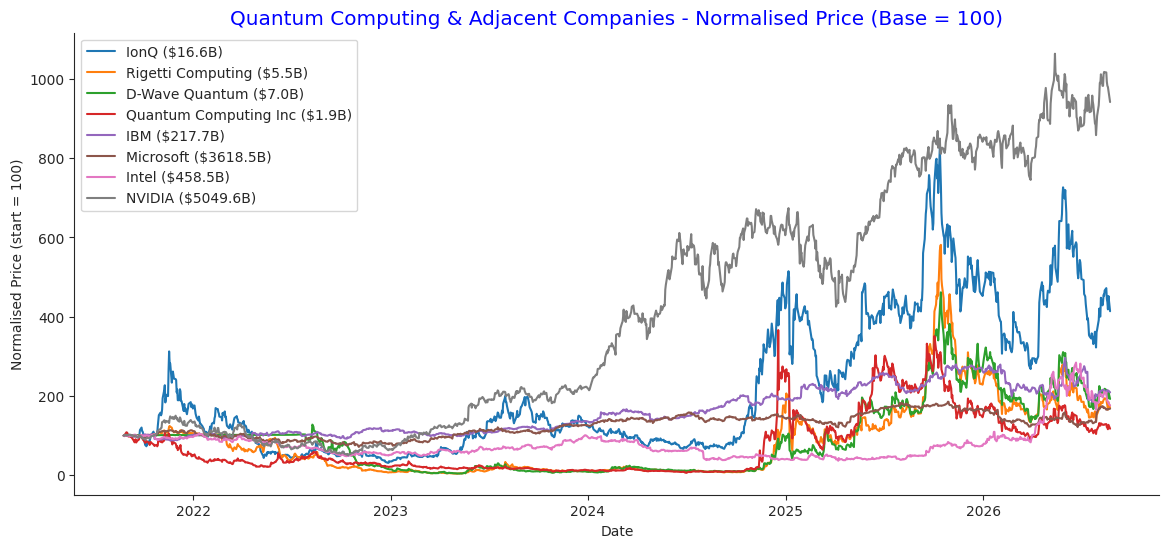

In [11]:
from MarketData.FundList import QuantumCompanyList, QuantumAdjacentCompanyList

combined_list = plot_normalised_comparison(
    lambda: {**QuantumCompanyList(), **QuantumAdjacentCompanyList()},
    "Quantum Computing & Adjacent Companies - Normalised Price (Base = 100)"
)


# Example of Excel generation for multiple funds with data checks


Submitted: 7IM
Submitted: abrdn Latin
Submitted: abrdn UK
Submitted: abrdn UK sus
Submitted: Artemis
Submitted: Artemis small
Submitted: Aviva
Submitted: Baillie Gifford
Submitted: Barclays Global
Submitted: Barings German
Submitted: Barings Korea
Submitted: Black Gold
Submitted: Black Natural
Submitted: CT Global Bond
Submitted: CT Global Real
Submitted: Fidelity Pacific
Submitted: Fidelity Sustainable
Submitted: GS Emerging
Submitted: GS India
Submitted: HSBC Europe
Submitted: HSBC FTSE 100
Submitted: HSBC All World
Submitted: HSBC Japan
Submitted: HSBC Gilt
Submitted: HSBC World
Submitted: Invesco Pacific
Submitted: Invesco China
Submitted: JPM Emerging
Submitted: Jupiter Global
Submitted: Jupiter Merlin
Submitted: L&G World Sus
Submitted: L&G Index
Submitted: M&G Global Emerging
Submitted: M&G Global Gov
Submitted: M&G Global Macro
Submitted: 91 Gold
Submitted: 91 Income
Submitted: Money Market
Submitted: Schroder Asian
Submitted: Schroder High Yield
Submitted: UBS S&P 500
Submitte


1 Failed download:
['']: ValueError('Empty ticker name')


[Aviva] FAILED: empty data from Yahoo
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[abrdn Latin] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Baillie Gifford] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[abrdn UK sus] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Artemis] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Artemis small] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[abrdn UK] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[7IM] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Barclays Global] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Barings German] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Barings Korea] OK
data start date = 202


1 Failed download:
['']: ValueError('Empty ticker name')

1 Failed download:
['']: ValueError('Empty ticker name')


data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[HSBC Japan] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[HSBC Gilt] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[HSBC All World] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[HSBC World] OK
[Invesco China] FAILED: empty data from Yahoo
[Invesco Pacific] FAILED: empty data from Yahoo



1 Failed download:
['']: ValueError('Empty ticker name')


[L&G World Sus] FAILED: empty data from Yahoo
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[JPM Emerging] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[L&G Index] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Jupiter Merlin] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[M&G Global Gov] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Jupiter Global] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[M&G Global Emerging] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[M&G Global Macro] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[91 Income] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[91 Gold] OK
data start date = 2025-12-15 00:00:00 when requested was 2025-12-14 00:00:00
[Money Market] O

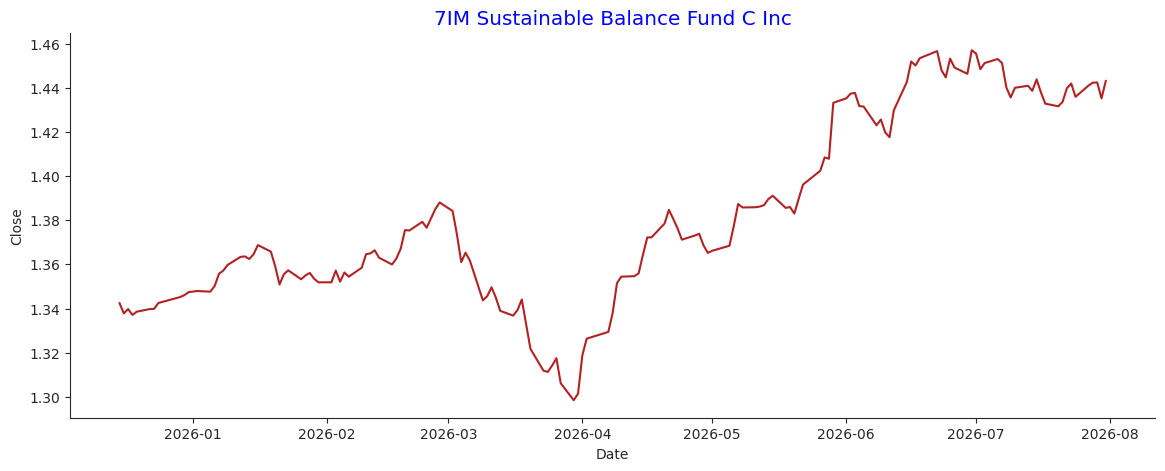

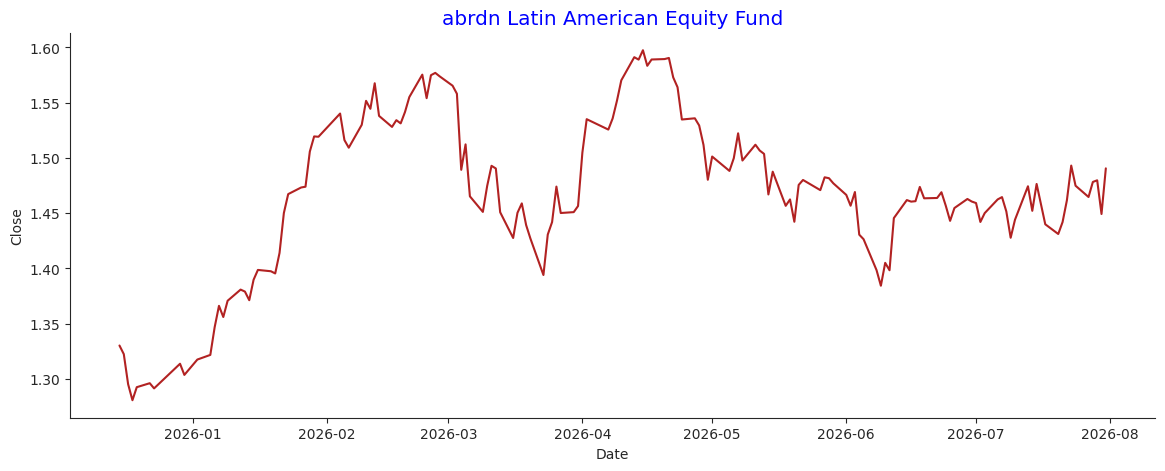

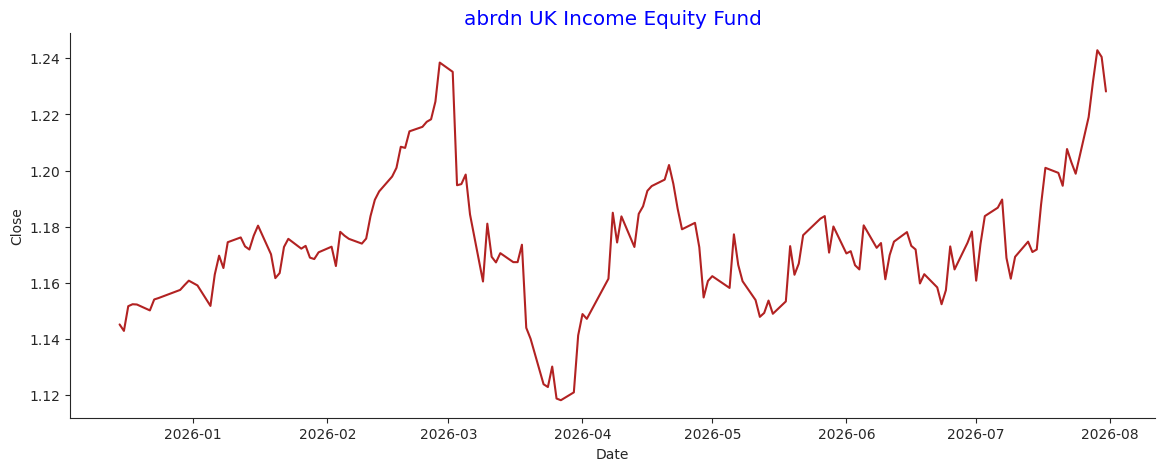

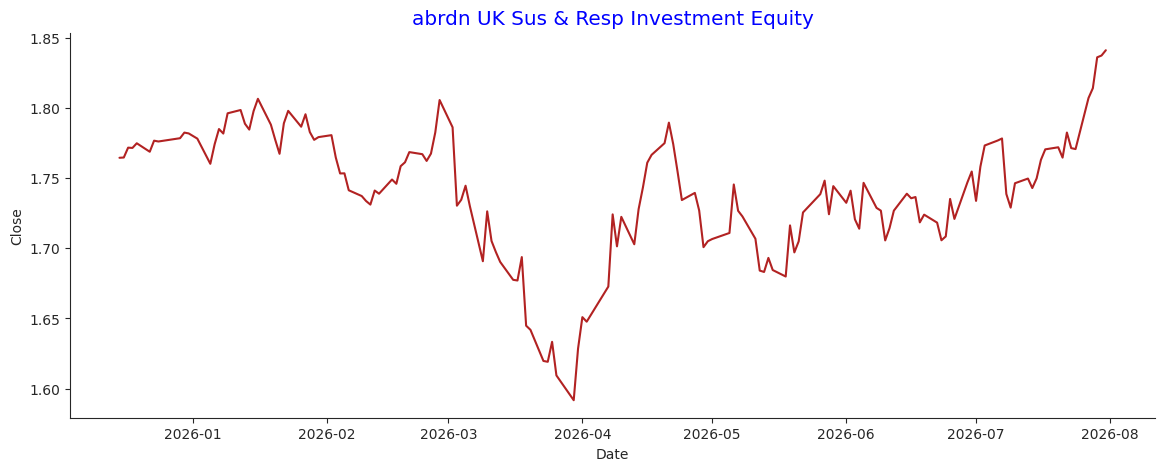

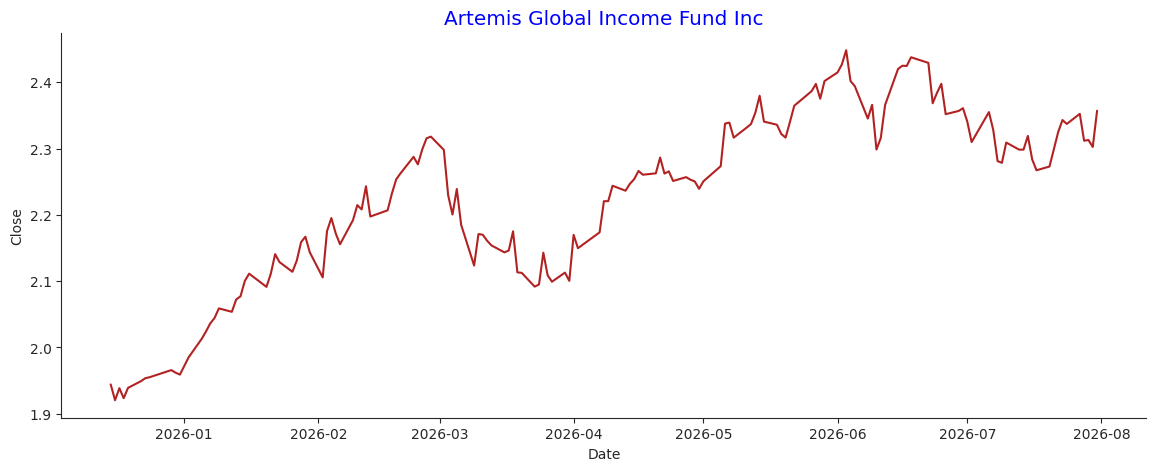

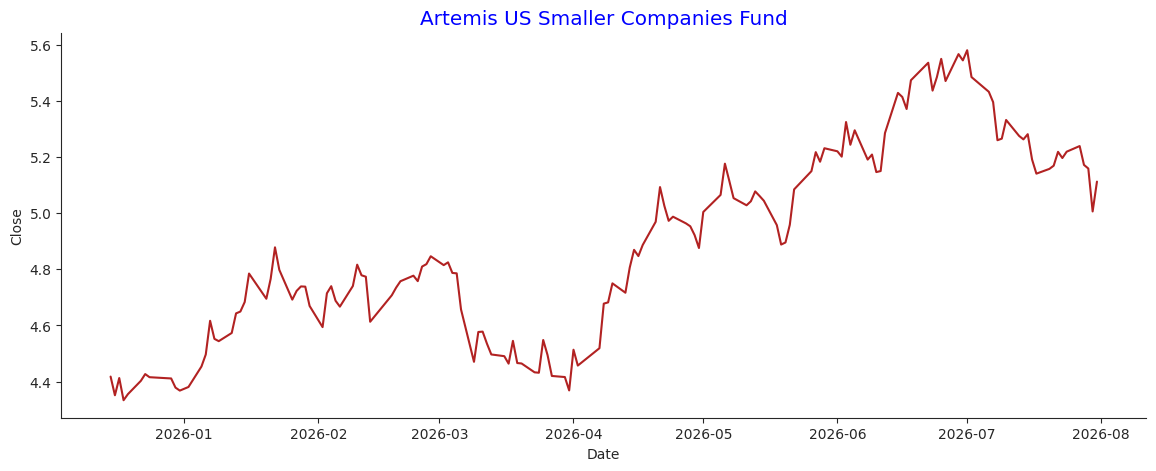

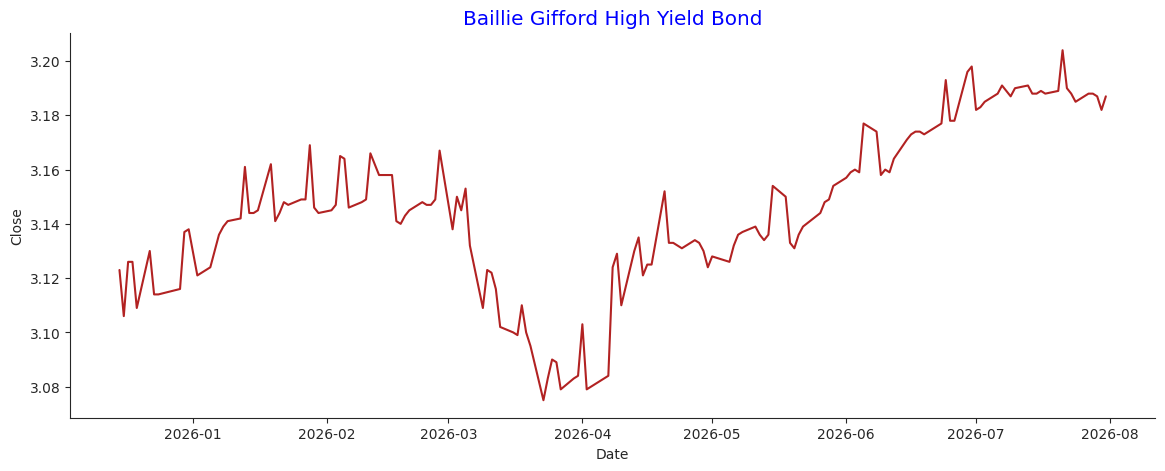

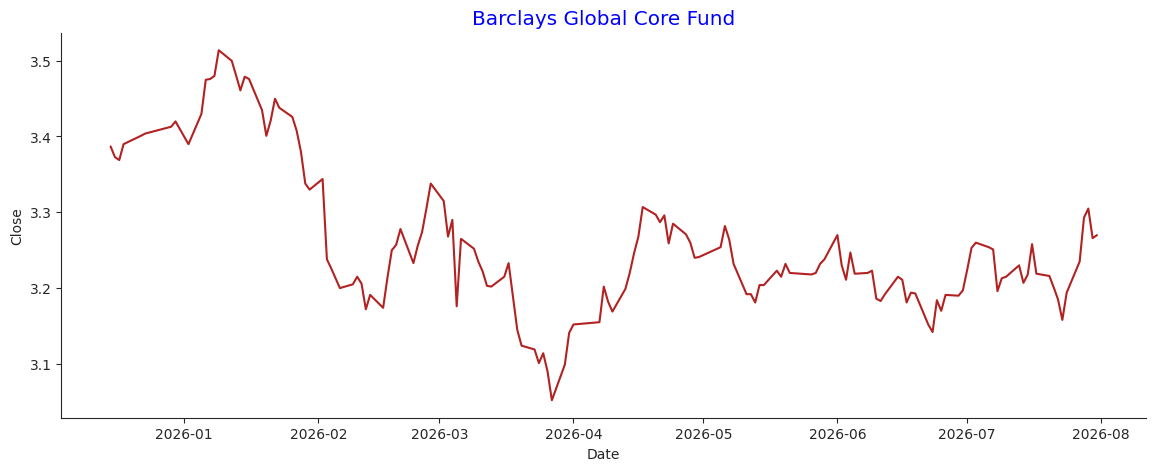

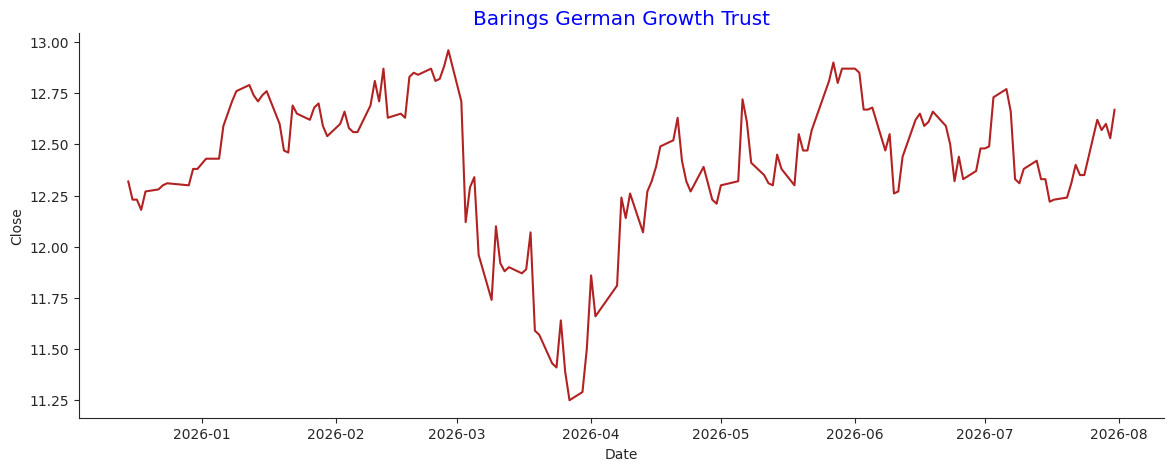

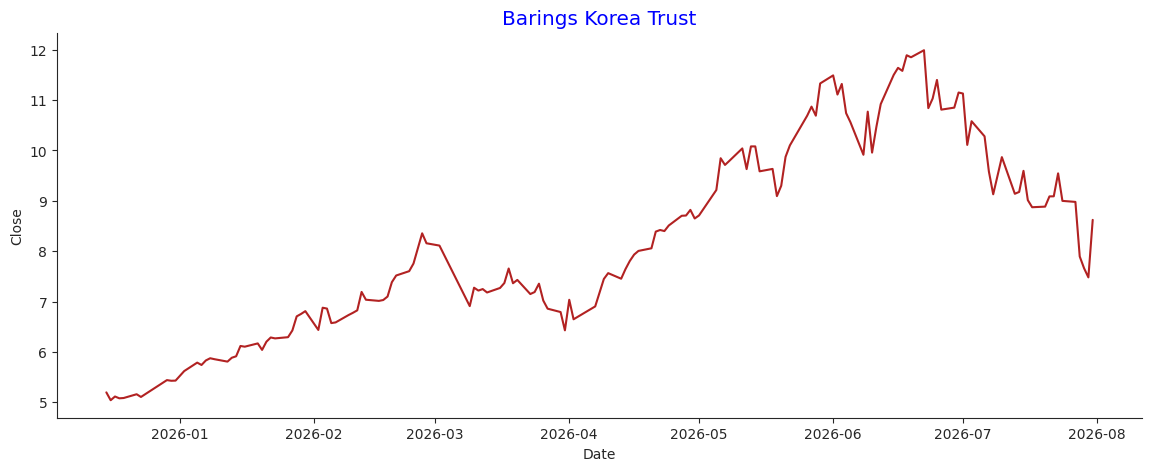

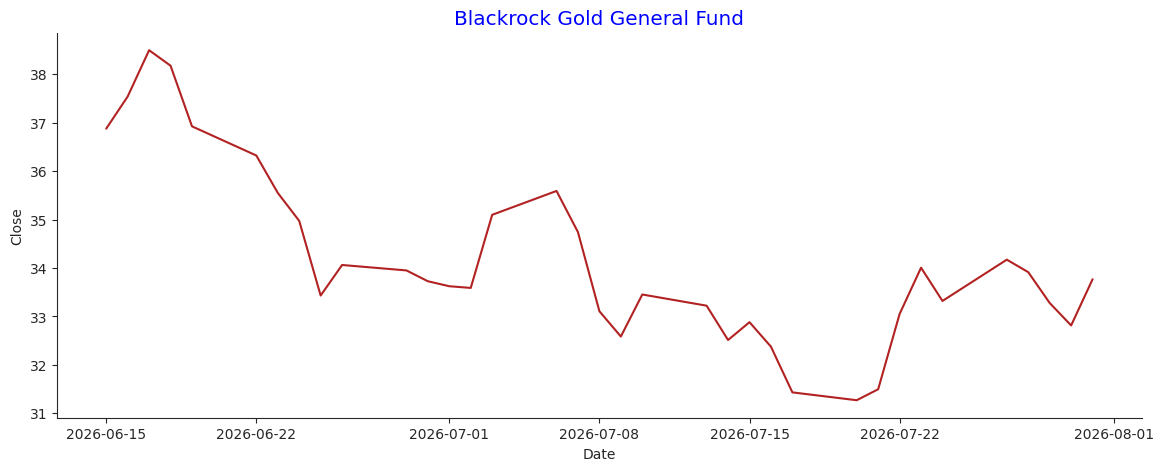

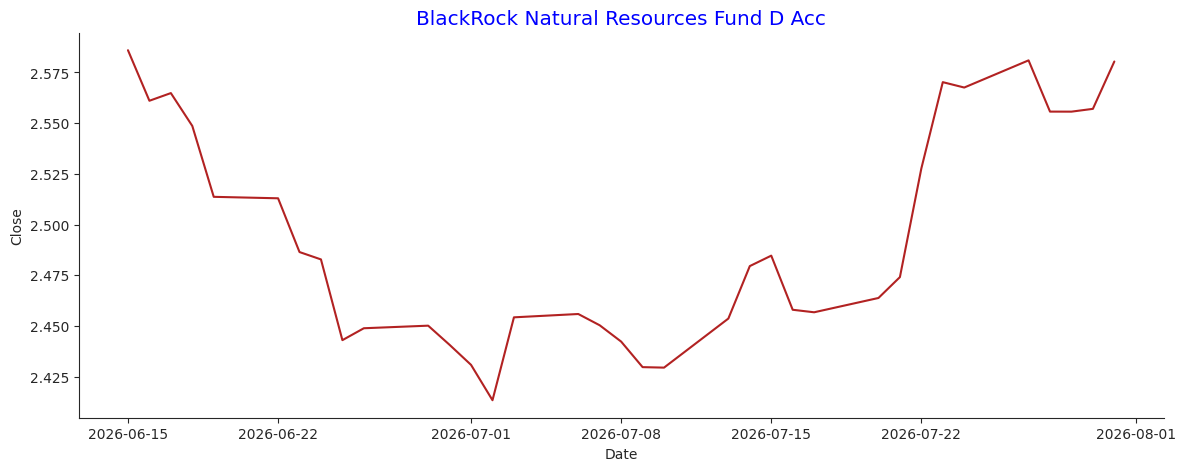

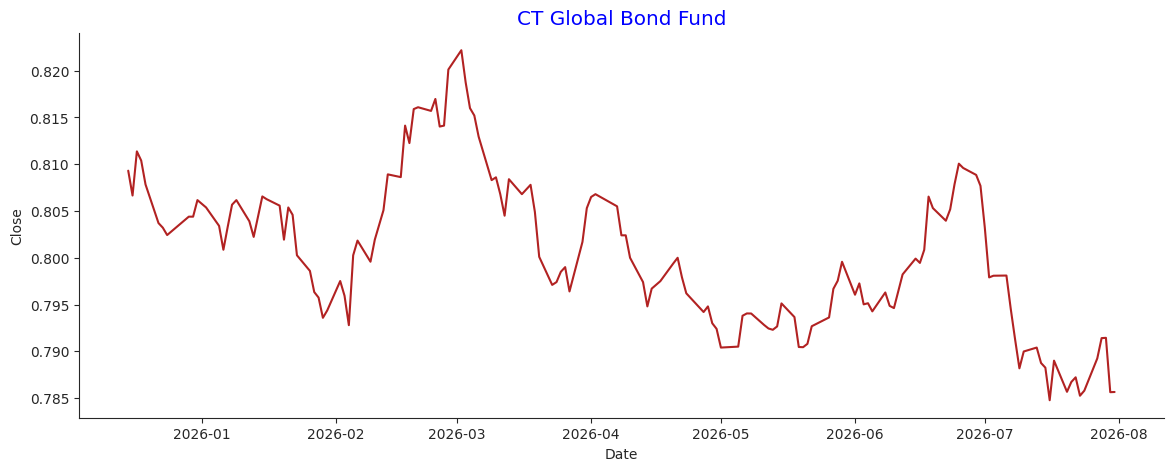

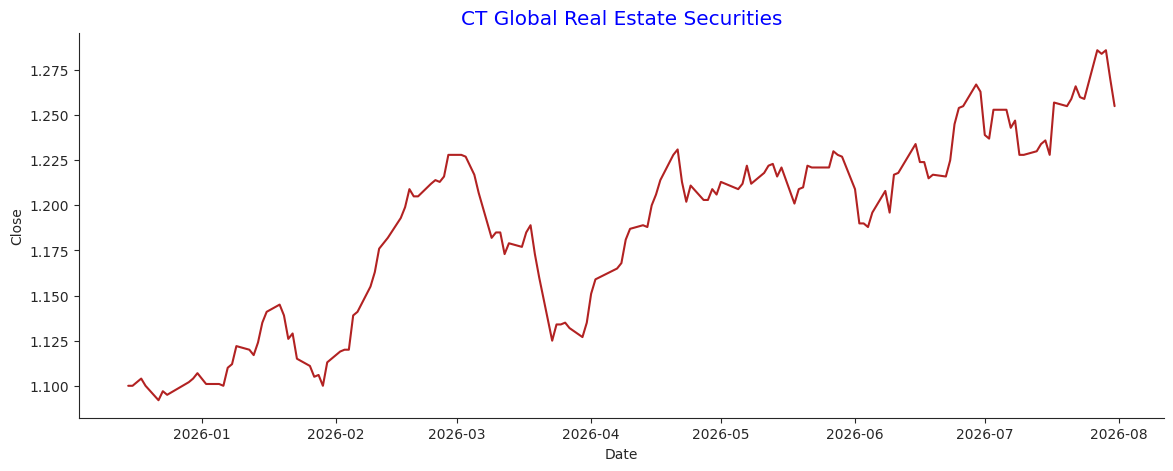

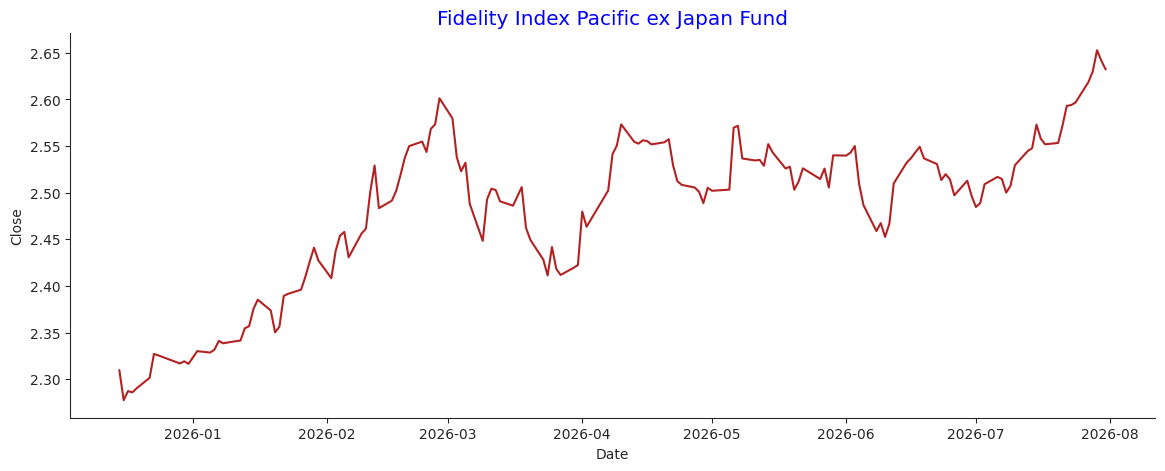

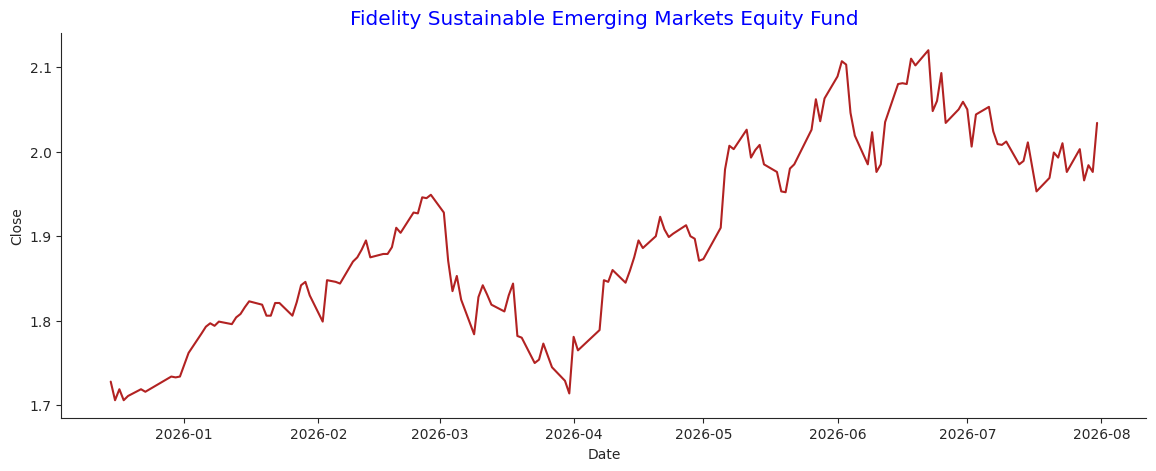

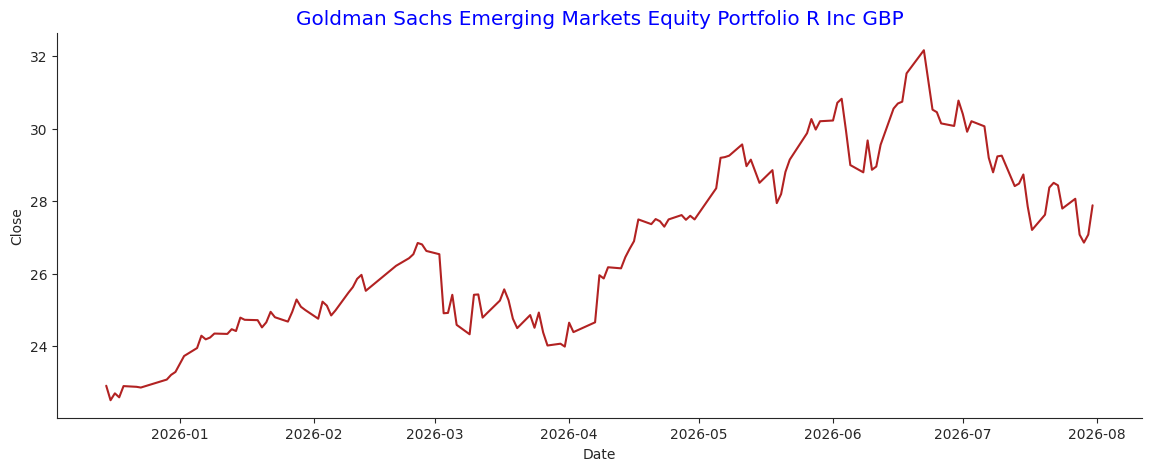

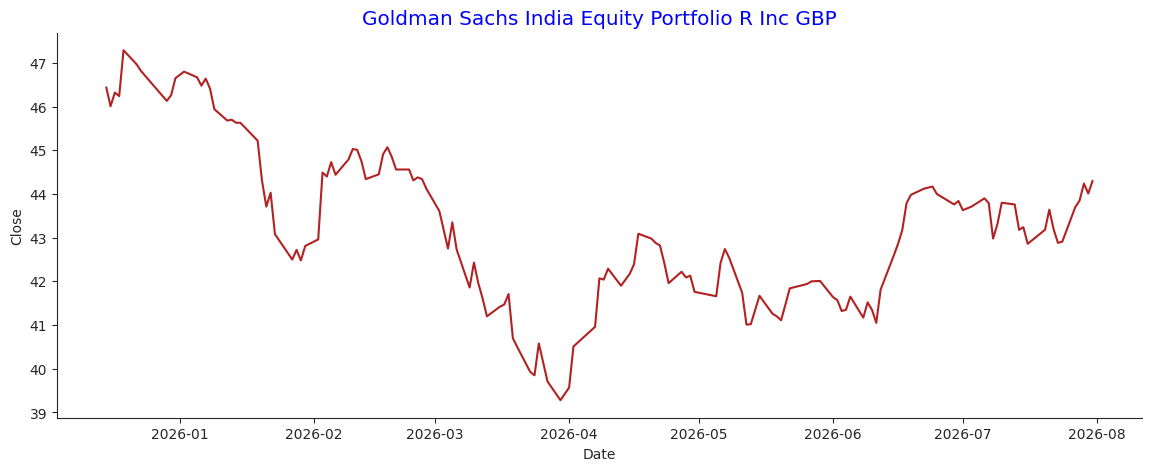

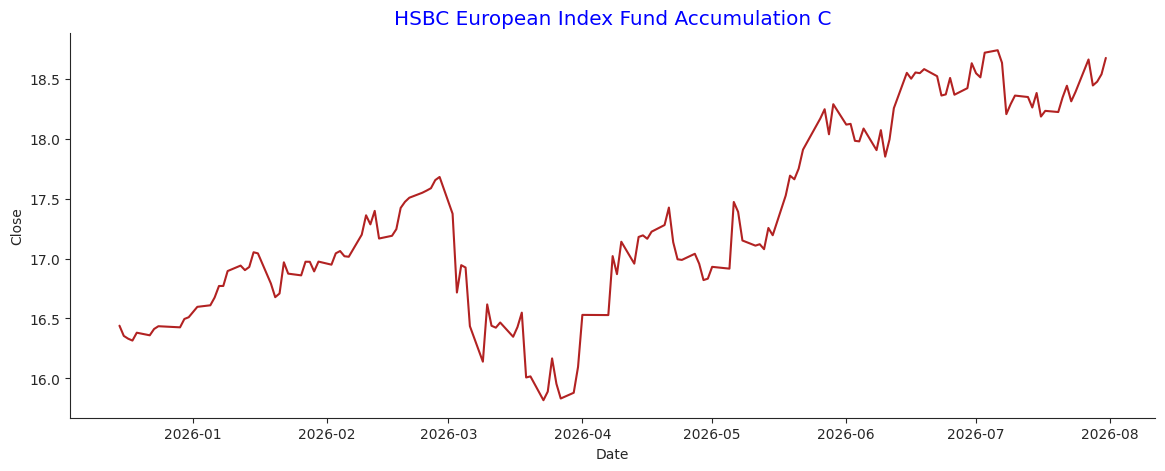

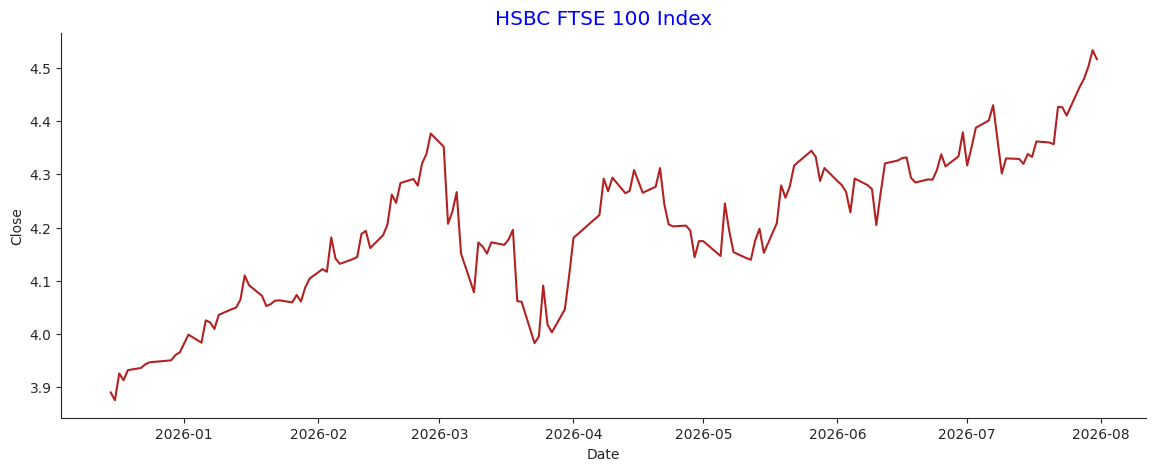

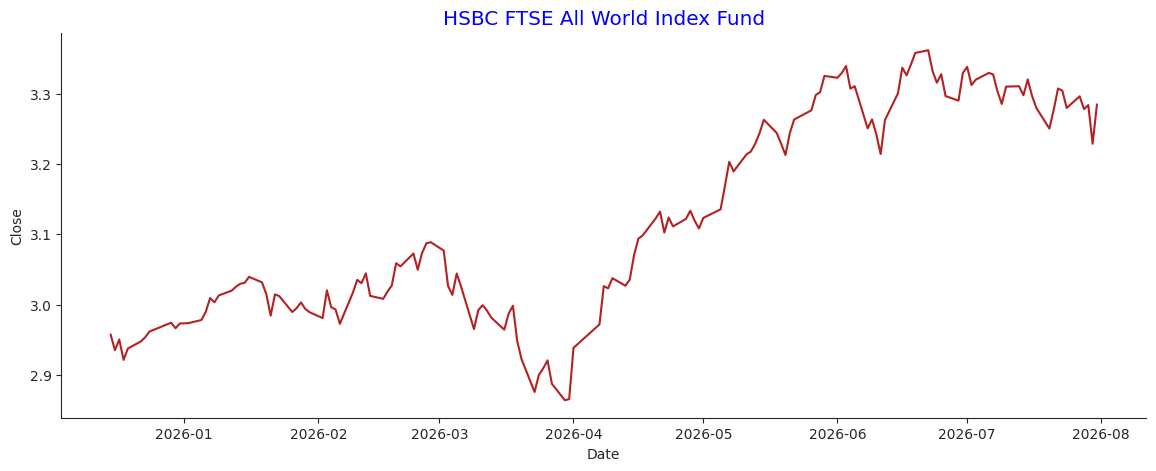

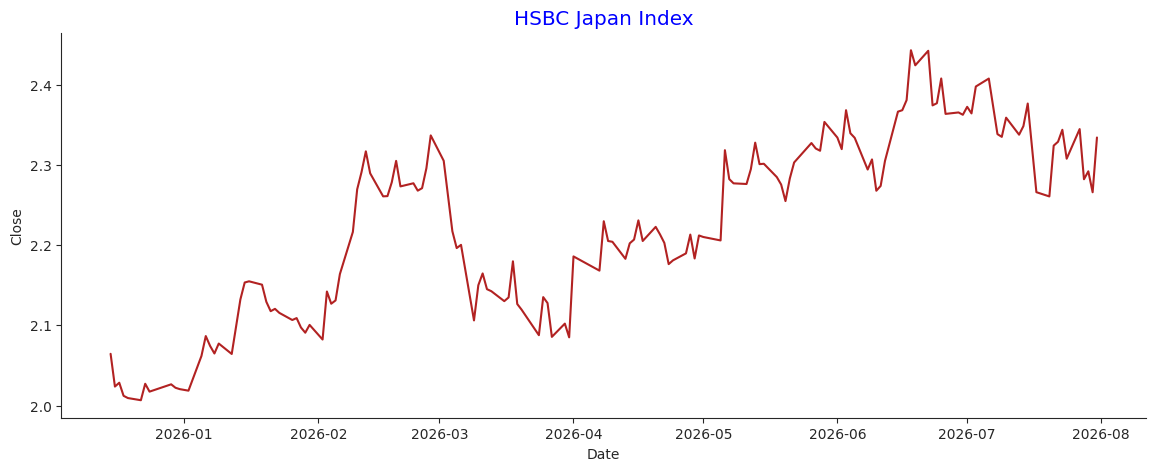

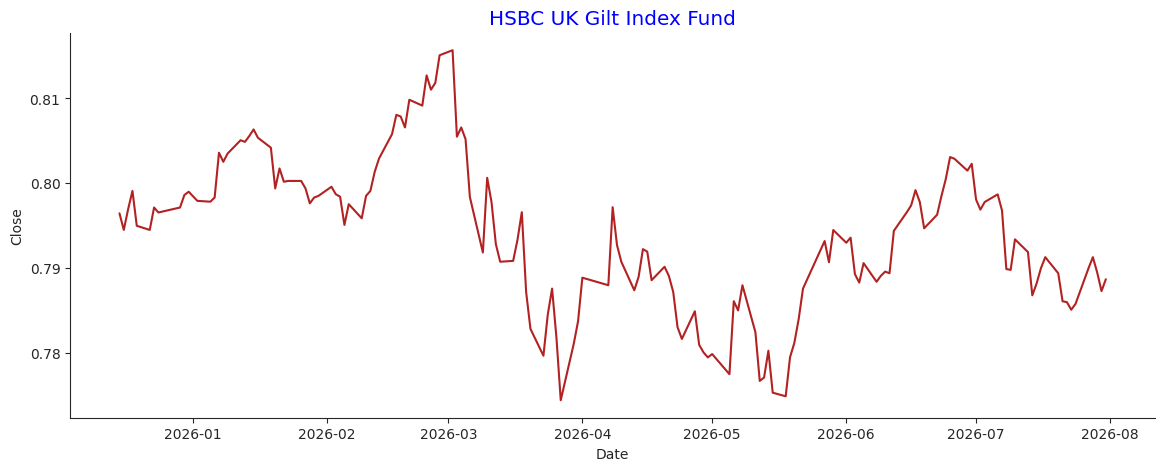

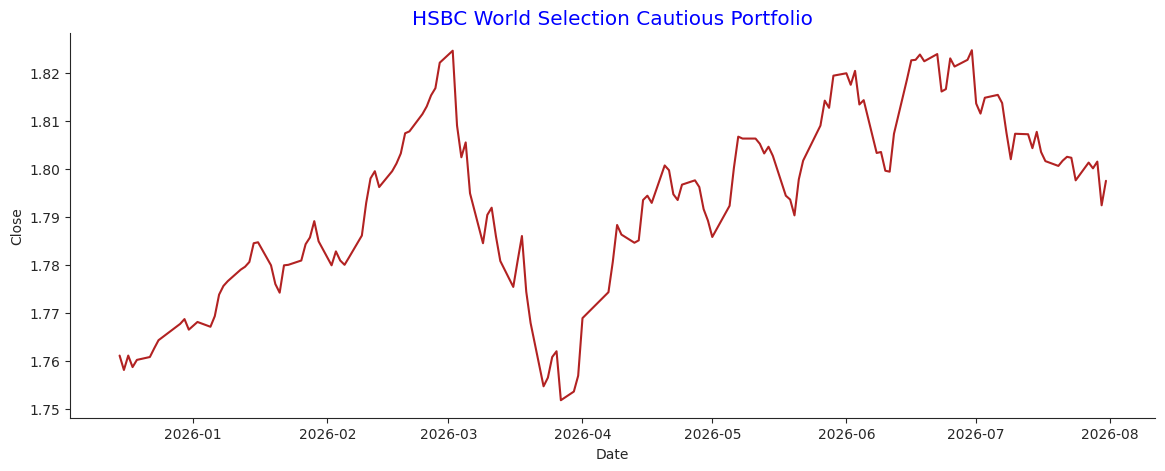

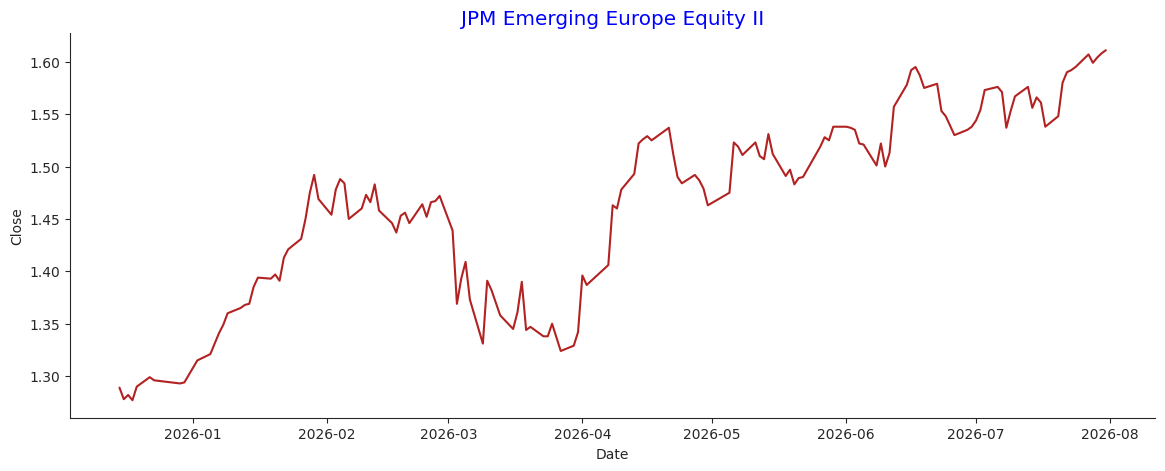

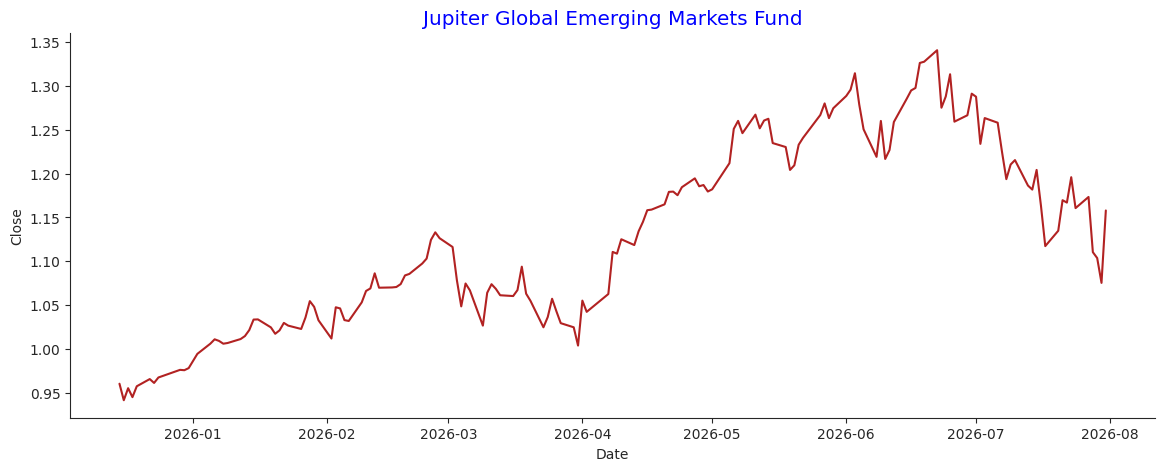

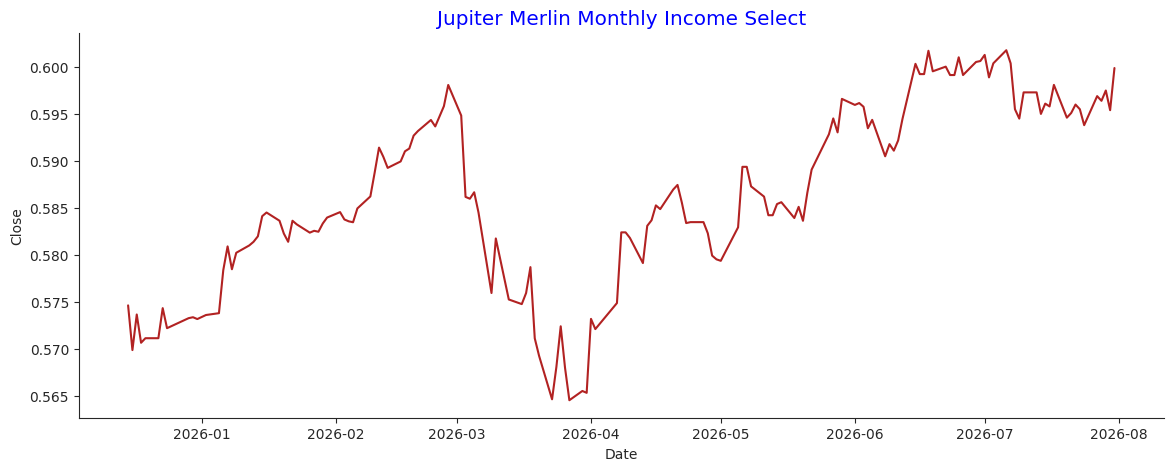

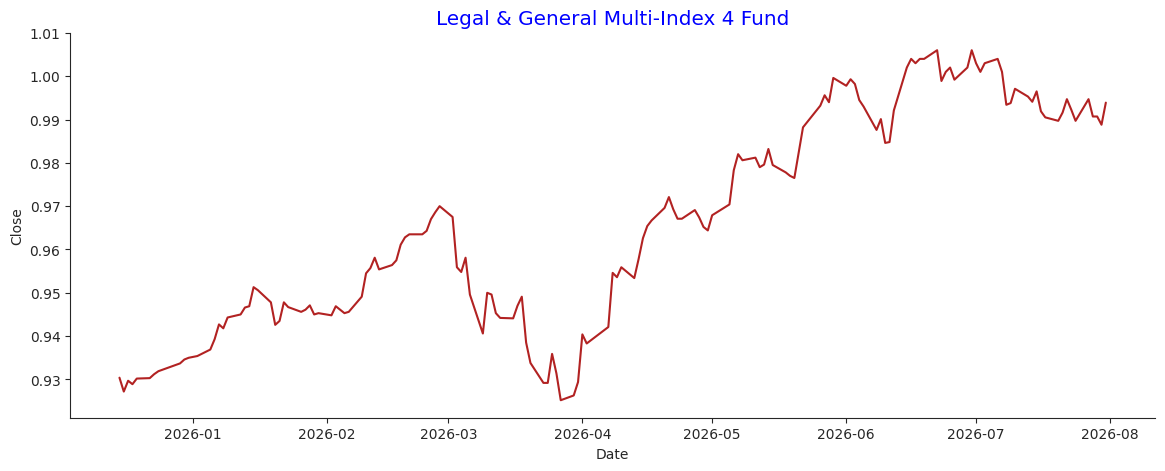

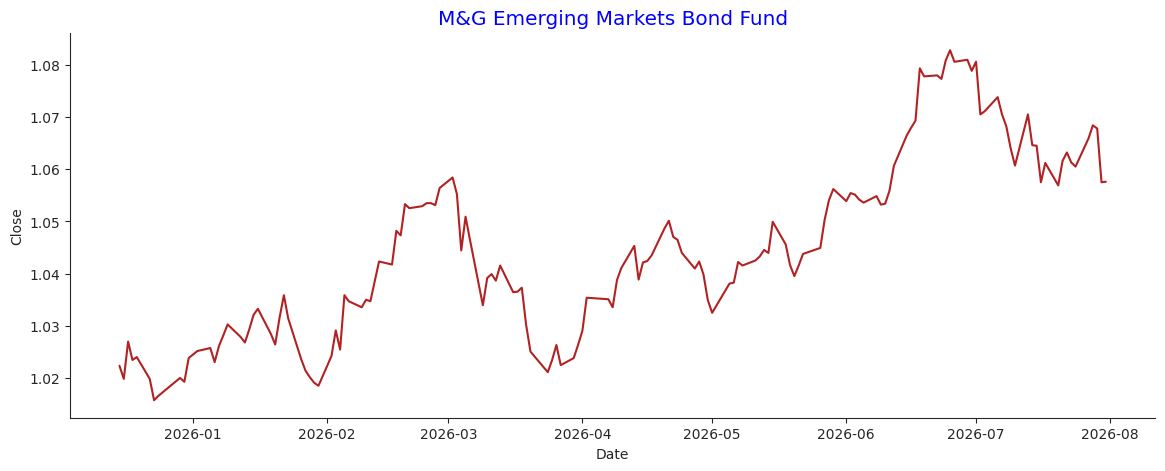

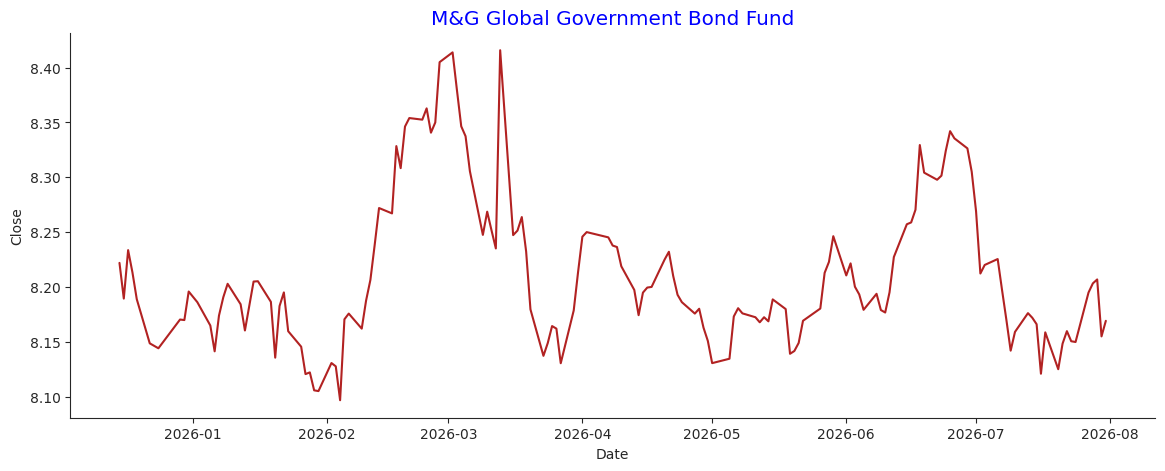

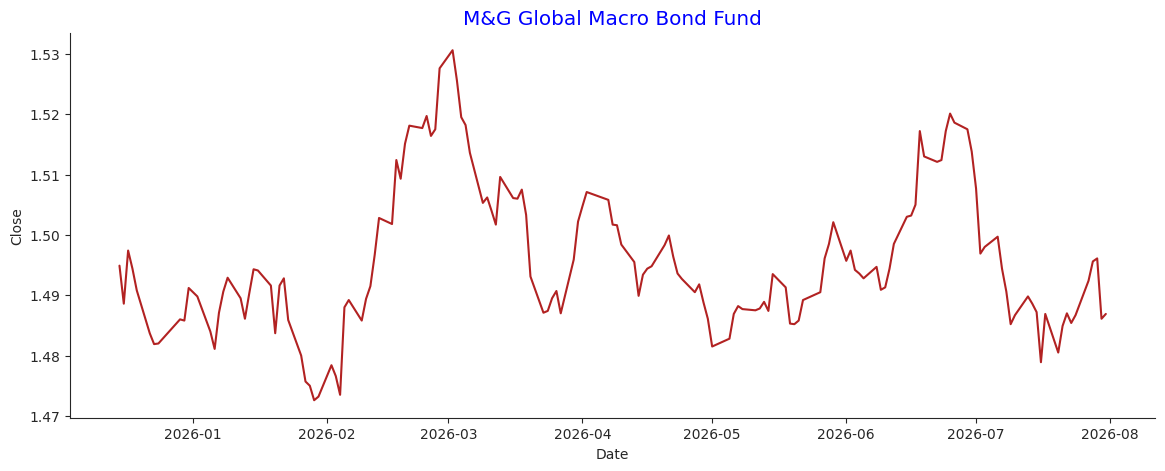

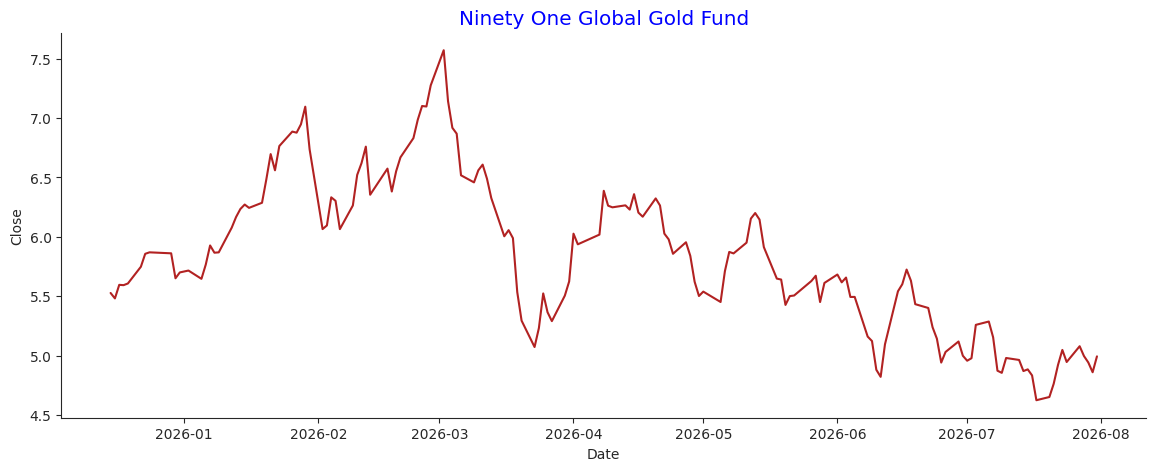

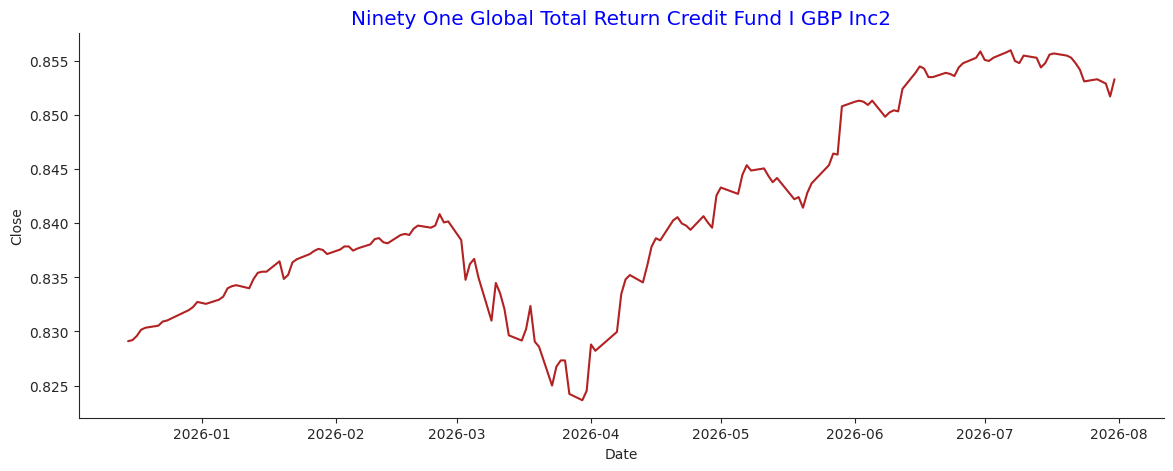

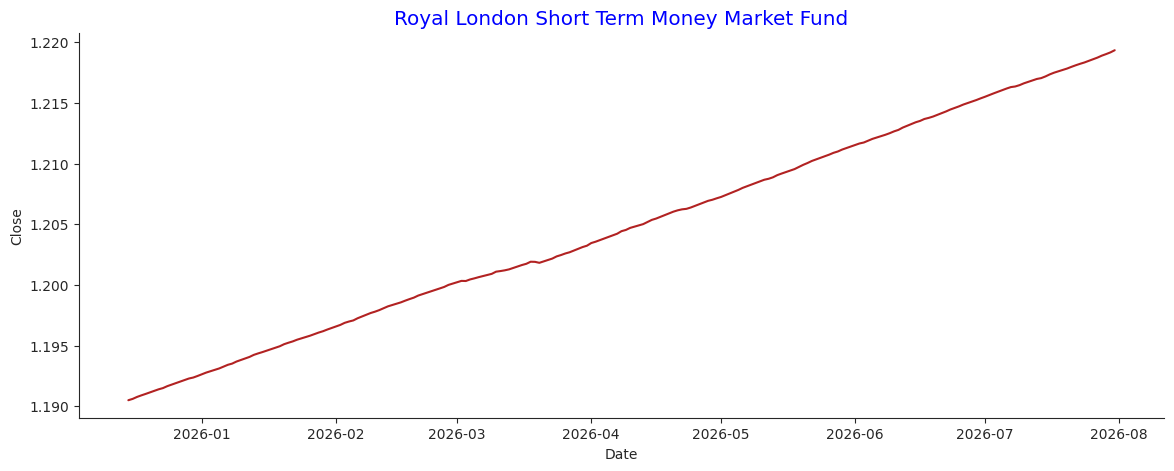

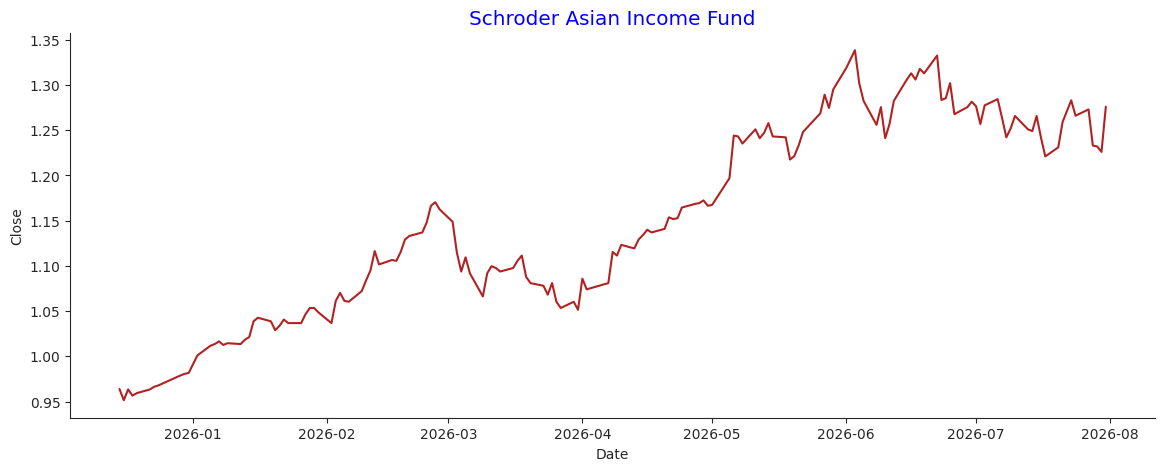

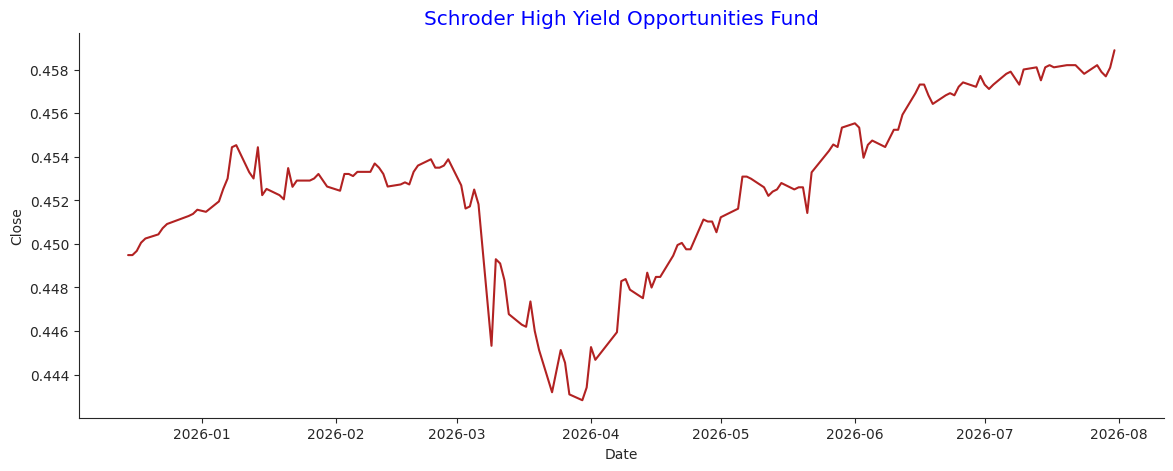

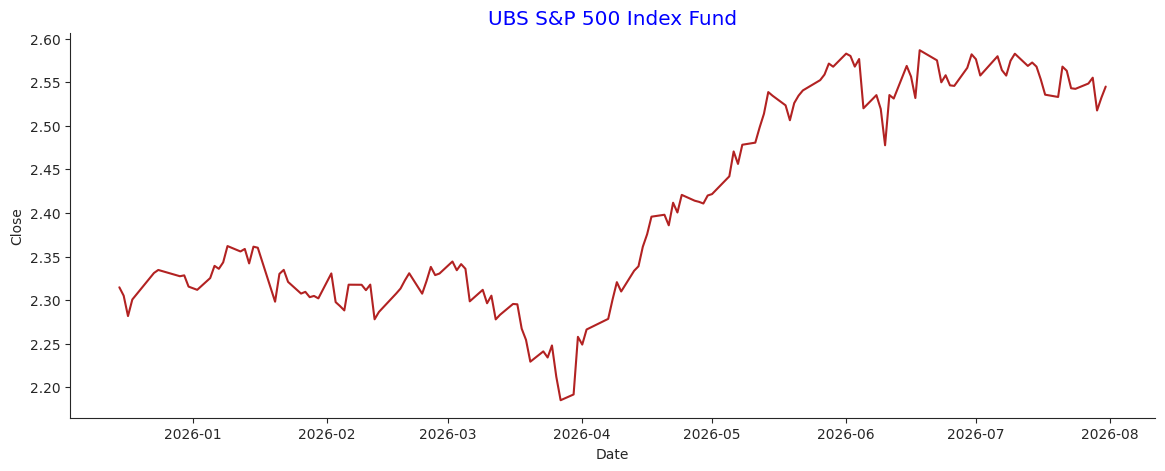

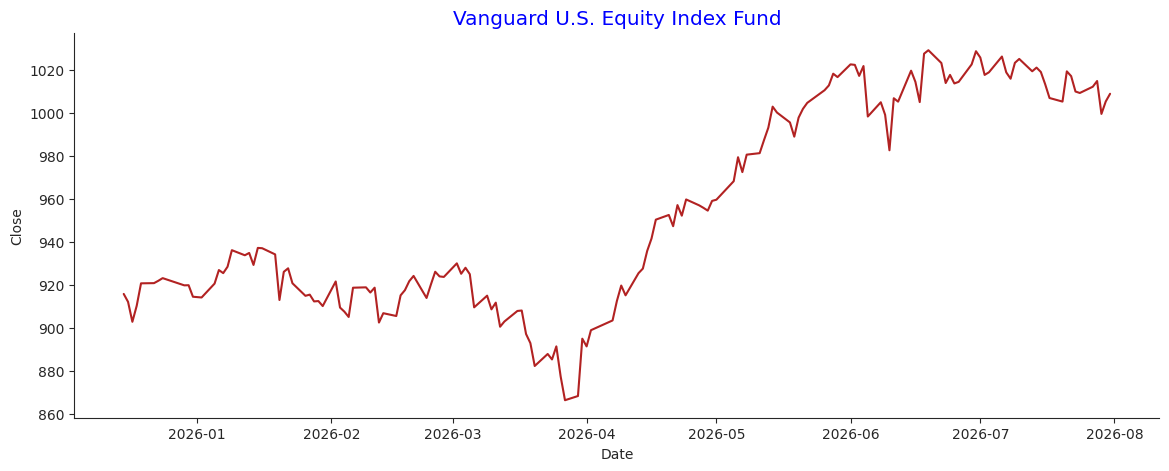

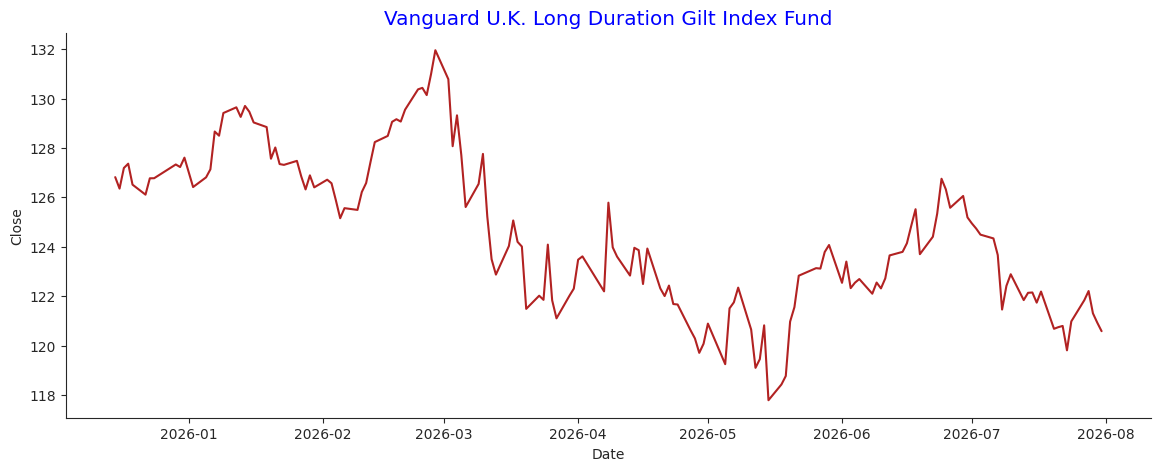

7IM Sustainable Balance Fund C Inc 6.9762627970124 4.186403291335239 0.001279016293389758
abrdn Latin American Equity Fund 10.754059941655745 1.4958237306636322 0.0033877654240482102
abrdn UK Income Equity Fund 6.757852749636801 4.3755469585969005 0.00045280963006319236
abrdn UK Sus & Resp Investment Equity 4.163543240923958 5.501855174377273 0.0012199641077727881
Artemis Global Income Fund Inc 17.522846475889626 5.47012538194979 0.007575195488001831
Artemis US Smaller Companies Fund 13.596980115137027 4.455583439075017 0.023186825894489917
Baillie Gifford High Yield Bond 2.008162189267543 1.2997832252012327 0.00026902281990153984
Barclays Global Core Fund -3.5738507750499546 0.35798163241367914 0.002778406331003332
Barings German Growth Trust 2.7624339334029733 2.0875589371686316 0.00973756489605707
Barings Korea Trust 39.73659629101347 4.646291016090019 0.42492756350195815
Blackrock Gold General Fund -9.207751353536183 -1.1393399474780157 0.09492658230989728
BlackRock Natural Resourc

In [3]:
from MarketData.FundList import FundList
import Globals.Functions as gf
import Globals.Variables as gv
from Report.ReportGenerator import FundReportGenerator
from MarketData.MarketDataPlotter import MarketDtaPlotter
from MarketData.MarketDataHelper import MarketDataHelper

fundList = FundList()
gf.populate_all_fund_data(gv.start_date, gv.end_date, fundList) # uses ThreadPoolExecutor
gf.plot_all_fund_data(fundList)
fundList = gf.get_all_fund_indicators(fundList)
reportGenerator = FundReportGenerator(fundList)
reportGenerator.write_to_excel("FundReport")
